In [1]:
import numpy as np
import matplotlib.pyplot as plt

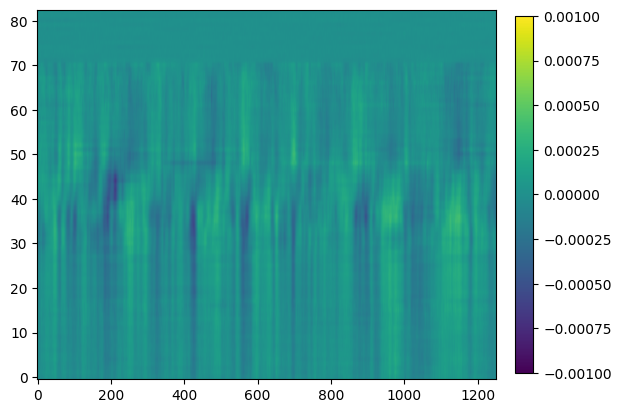

In [8]:
lfp_slice=np.load('/home/maria/LFPExperiments/data/1sec_first_data.npy')
im=plt.imshow(lfp_slice.T, aspect='auto',origin='lower',vmin=-1e-3, vmax=1e-3)
_ = plt.colorbar(im, fraction=0.036, pad=0.04)

(array([2.1000e+01, 1.0000e+02, 4.0900e+02, 1.2210e+03, 6.8170e+03,
        2.7117e+04, 5.1707e+04, 1.3706e+04, 2.4560e+03, 1.9600e+02]),
 array([-6.80744997e-04, -5.70881995e-04, -4.61018994e-04, -3.51155992e-04,
        -2.41293004e-04, -1.31430003e-04, -2.15670043e-05,  8.82959939e-05,
         1.98158988e-04,  3.08021990e-04,  4.17884992e-04]),
 <BarContainer object of 10 artists>)

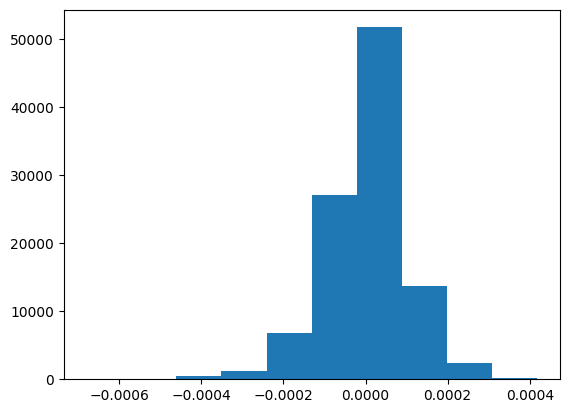

In [15]:
#plt.plot(lfp_slice[:,0])
#plt.plot(lfp_slice[:,1])
plt.hist(lfp_slice.flatten())

Data shape: (1250, 83)


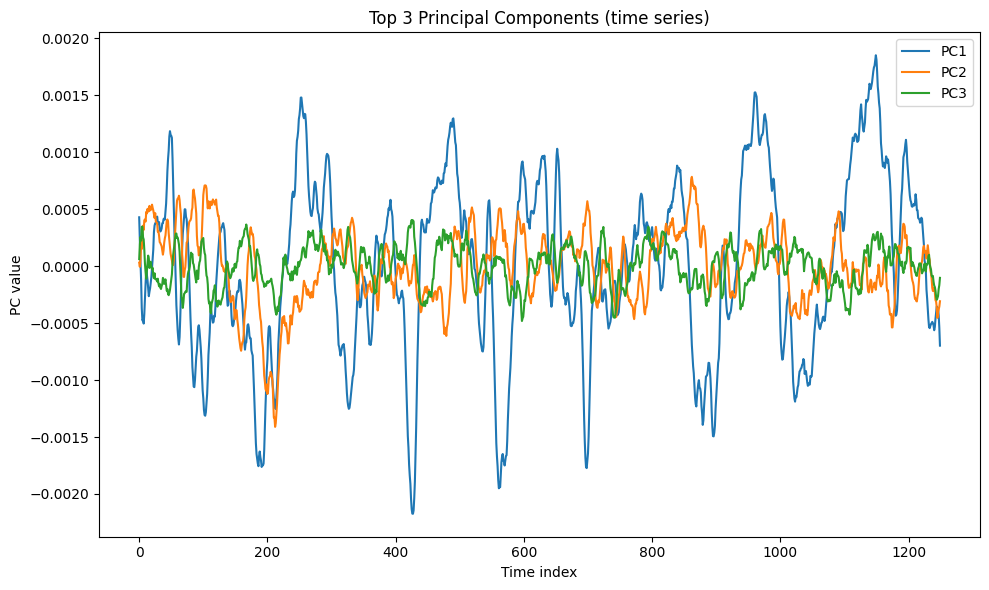

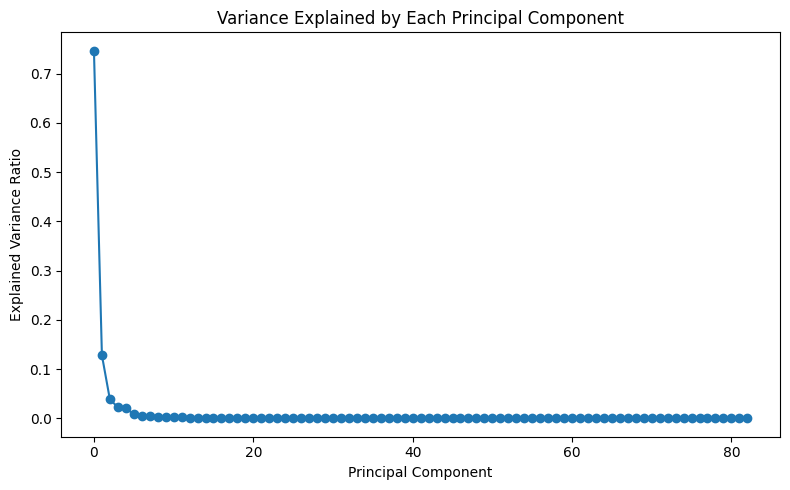

PC1..PC1 explain 0.747 variance
PC1..PC2 explain 0.875 variance
PC1..PC3 explain 0.913 variance
PC1..PC4 explain 0.936 variance
PC1..PC5 explain 0.956 variance
PC1..PC6 explain 0.965 variance
PC1..PC7 explain 0.970 variance
PC1..PC8 explain 0.975 variance
PC1..PC9 explain 0.978 variance
PC1..PC10 explain 0.981 variance


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# -----------------------------
# Load data
# -----------------------------
lfp_slice = np.load('/home/maria/LFPExperiments/data/1sec_first_data.npy')

print("Data shape:", lfp_slice.shape)

# -----------------------------
# Run PCA
# -----------------------------
pca = PCA()
X_pca = pca.fit_transform(lfp_slice)

explained_variance = pca.explained_variance_ratio_

# -----------------------------
# Plot top 3 PCs over time
# -----------------------------
plt.figure(figsize=(10,6))

for i in range(3):
    plt.plot(X_pca[:, i], label=f'PC{i+1}')

plt.title("Top 3 Principal Components (time series)")
plt.xlabel("Time index")
plt.ylabel("PC value")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Plot variance explained
# -----------------------------
plt.figure(figsize=(8,5))

plt.plot(explained_variance, marker='o')
plt.title("Variance Explained by Each Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")

plt.tight_layout()
plt.show()

# -----------------------------
# Print cumulative variance
# -----------------------------
cum_var = np.cumsum(explained_variance)

for i in range(10):
    print(f"PC1..PC{i+1} explain {cum_var[i]:.3f} variance")

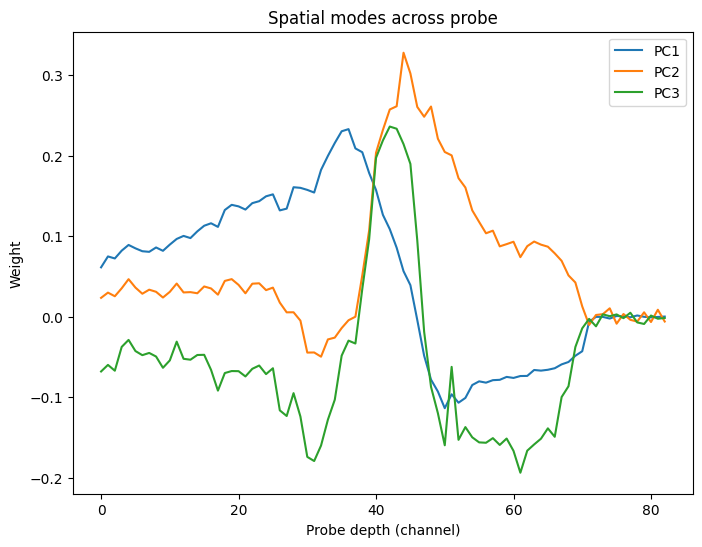

In [2]:
plt.figure(figsize=(8,6))

for i in range(3):
    plt.plot(pca.components_[i], label=f'PC{i+1}')

plt.xlabel("Probe depth (channel)")
plt.ylabel("Weight")
plt.title("Spatial modes across probe")
plt.legend()
plt.show()

Text(0, 0.5, 'Cumulative variance')

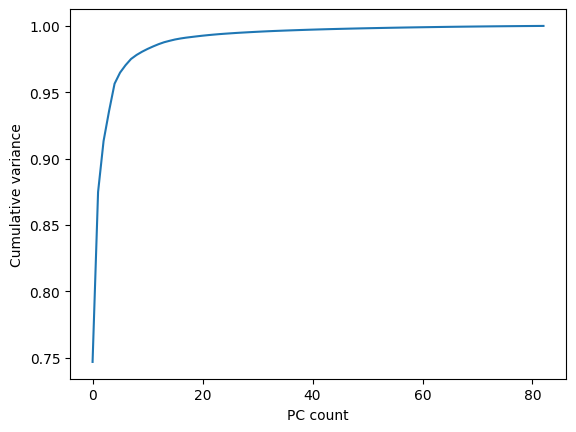

In [3]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("PC count")
plt.ylabel("Cumulative variance")

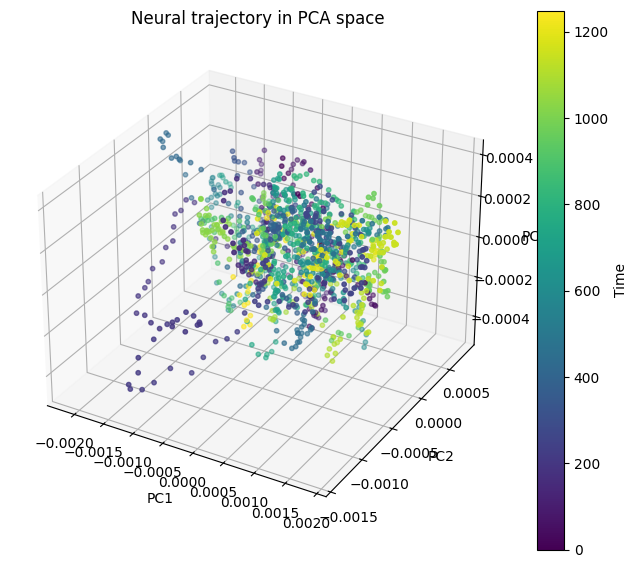

In [4]:
pca = PCA()
X_pca = pca.fit_transform(lfp_slice)

pc1 = X_pca[:,0]
pc2 = X_pca[:,1]
pc3 = X_pca[:,2]

# -----------------------------
# 3D trajectory plot
# -----------------------------
fig = plt.figure(figsize=(8,7))
ax = fig.add_subplot(111, projection='3d')

# color by time
t = np.arange(len(pc1))

scatter = ax.scatter(
    pc1,
    pc2,
    pc3,
    c=t,
    cmap='viridis',
    s=10
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Neural trajectory in PCA space")

fig.colorbar(scatter, label="Time")

plt.show()

In [1]:
import numpy as np
from sklearn.decomposition import PCA
import plotly.graph_objects as go

# -----------------------------
# Load LFP data
# -----------------------------
lfp_slice = np.load('/home/maria/LFPExperiments/data/1sec_first_data.npy')

print("Data shape:", lfp_slice.shape)

# -----------------------------
# Run PCA
# -----------------------------
pca = PCA()
X_pca = pca.fit_transform(lfp_slice)

pc1 = X_pca[:, 0]
pc2 = X_pca[:, 1]
pc3 = X_pca[:, 2]

# time index for coloring
t = np.arange(len(pc1))

# -----------------------------
# Create Plotly figure
# -----------------------------
fig = go.Figure()

# trajectory line
fig.add_trace(
    go.Scatter3d(
        x=pc1,
        y=pc2,
        z=pc3,
        mode='lines',
        line=dict(width=3, color='black'),
        name='trajectory'
    )
)

# colored points
fig.add_trace(
    go.Scatter3d(
        x=pc1,
        y=pc2,
        z=pc3,
        mode='markers',
        marker=dict(
            size=4,
            color=t,
            colorscale='Viridis',
            colorbar=dict(title="Time"),
            opacity=0.8
        ),
        name='timepoints'
    )
)

# layout
fig.update_layout(
    title="Neural Trajectory in PCA Space (LFP)",
    scene=dict(
        xaxis_title="PC1",
        yaxis_title="PC2",
        zaxis_title="PC3"
    ),
    width=900,
    height=700
)

fig.show()

Data shape: (1250, 83)
